# ChemWorld Physics Sanity Check

This notebook probes whether `ChemWorld` behaves like a plausible semi-mechanistic physical-chemical world rather than an arbitrary black-box function. It keeps the hidden world seed fixed and scans one factor at a time.

## Kernel

Use the `Python (ChemWorld)` Jupyter kernel installed from the project `.venv`. If imports fail, run `python -m pip install -e ".[dev,notebooks]"` in the project root and reinstall the kernel with `python -m ipykernel install --user --name chemworld --display-name "Python (ChemWorld)"`.


In [1]:
import math
from pathlib import Path

import gymnasium as gym
import pandas as pd

import chemworld  # registers ChemWorld

pd.set_option("display.precision", 4)
ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
print("chemworld version:", chemworld.__version__)
print("project root:", ROOT)

chemworld version: 0.1.0
project root: D:\Projects\ChemWorld


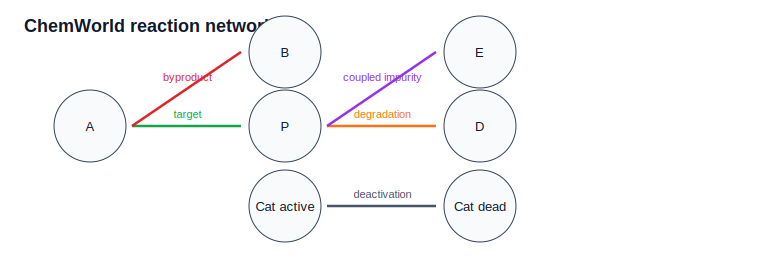

In [2]:
import importlib
import sys

from IPython.display import display

sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))
tu = importlib.import_module("tutorial_utils")

tu.display_project_canvas(
    title="Physics sanity before benchmark claims",
    problem="Do scans show recognizable chemistry trade-offs instead of score hacking?",
    strategy=(
        "Hold the hidden world fixed and vary temperature, time, catalyst, "
        "solvent, and concentration."
    ),
    artifact="Sanity tables and plots that can be cited in the architecture report.",
    risks="Passing sanity checks does not mean this is a real reaction predictor.",
)
display(tu.reaction_network_svg())


In [3]:
def scalar(observation, key: str) -> float | None:
    value = float(observation[key][0])
    return None if math.isnan(value) else value


def run_recipe(
    *,
    target_temperature_K: float = 390.0,
    duration_s: float = 300.0,
    catalyst: int = 1,
    solvent: int = 2,
    amount_mol: float = 0.010,
    seed: int = 31,
) -> dict[str, float | int | None]:
    actions = [
        {"operation": "add_solvent", "volume_L": 0.030, "solvent": solvent},
        {"operation": "add_reagent", "amount_mol": amount_mol},
        {"operation": "add_catalyst", "catalyst_amount_mol": 0.00025, "catalyst": catalyst},
        {
            "operation": "heat",
            "target_temperature_K": target_temperature_K,
            "duration_s": duration_s,
            "stirring_speed_rpm": 720.0,
        },
        {"operation": "terminate"},
        {"operation": "measure", "instrument": "final_assay"},
    ]
    env = gym.make(
        "ChemWorld",
        world_split="public-dev",
        budget=len(actions),
        seed=seed,
    )
    env.reset(seed=seed)
    try:
        for action in actions:
            observation, _reward, _terminated, _truncated, info = env.step(action)
        return {
            "temperature_K": target_temperature_K,
            "duration_s": duration_s,
            "catalyst": catalyst,
            "solvent": solvent,
            "amount_mol": amount_mol,
            "yield": scalar(observation, "yield"),
            "selectivity": scalar(observation, "selectivity"),
            "conversion": scalar(observation, "conversion"),
            "degradation": scalar(observation, "degradation_warning"),
            "byproduct": scalar(observation, "byproduct_signal"),
            "risk": scalar(observation, "safety_risk"),
            "cost": scalar(observation, "cost"),
            "score": scalar(observation, "score"),
            "leaderboard_score": info["leaderboard_score"],
            "observed_keys": len(info["observed_keys"]),
        }
    finally:
        env.close()

## Temperature Scan

At a fixed short reaction time, moderate heating improves conversion, while excessive heating increases degradation and risk.


In [4]:
temperature_df = pd.DataFrame(
    run_recipe(target_temperature_K=temp, duration_s=300.0)
    for temp in [300.0, 330.0, 360.0, 390.0, 420.0, 450.0]
)
temperature_df[["temperature_K", "yield", "conversion", "degradation", "risk", "score"]]

,temperature_K,yield,conversion,degradation,risk,score
0,300.0,0.2139,0.2437,0.0062,0.0943,0.2732
1,330.0,0.4691,0.5234,0.0071,0.0973,0.4289
2,360.0,0.7138,0.8075,0.0127,0.1067,0.5731
3,390.0,0.8171,0.9560,0.0317,0.1632,0.6178
4,420.0,0.8045,0.9968,0.0732,0.3162,0.5653
5,450.0,0.7456,1.0000,0.1355,0.3922,0.5010


## Time Scan

Longer reaction time can initially help conversion, but product degradation eventually dominates.


In [5]:
time_df = pd.DataFrame(
    run_recipe(target_temperature_K=360.0, duration_s=time_s)
    for time_s in [60.0, 120.0, 300.0, 600.0, 900.0, 1800.0, 3600.0]
)
time_df[["duration_s", "yield", "conversion", "degradation", "risk", "score"]]

,duration_s,yield,conversion,degradation,risk,score
0,60.0,0.1022,0.1270,0.0062,0.0991,0.1925
1,120.0,0.3199,0.3654,0.0067,0.1052,0.3329
2,300.0,0.7138,0.8075,0.0127,0.1067,0.5731
3,600.0,0.8498,0.9753,0.0272,0.1066,0.6539
4,900.0,0.8563,1.0000,0.0426,0.1066,0.6555
5,1800.0,0.8154,1.0000,0.0878,0.1066,0.6227
6,3600.0,0.7320,1.0000,0.1712,0.1066,0.5579


## Catalyst-Solvent Interaction

The best condition is not a single globally dominant catalyst or solvent; interactions matter.


In [6]:
interaction_df = pd.DataFrame(
    run_recipe(catalyst=catalyst, solvent=solvent, target_temperature_K=360.0, duration_s=600.0)
    for catalyst in range(4)
    for solvent in range(4)
)
interaction_df.pivot(index="catalyst", columns="solvent", values="score")

solvent,0,1,2,3
catalyst,,,,
0,0.6073,0.4810,0.5959,0.4623
1,0.6742,0.5704,0.6539,0.5579
2,0.5231,0.3901,0.5163,0.3748
3,0.6517,0.5425,0.6393,0.5330


## Concentration-Risk Trade-off

Higher initial reagent loading increases the pressure/risk proxy and can reduce balanced objective score even when conversion remains high.


In [7]:
risk_df = pd.DataFrame(
    run_recipe(amount_mol=amount, target_temperature_K=390.0, duration_s=1800.0)
    for amount in [0.004, 0.008, 0.012, 0.016, 0.020]
)
risk_df[["amount_mol", "yield", "conversion", "risk", "score"]]

,amount_mol,yield,conversion,risk,score
0,0.004,0.6343,1.0,0.1507,0.4785
1,0.008,0.6317,1.0,0.1578,0.4730
2,0.012,0.6292,1.0,0.1694,0.4664
3,0.016,0.6266,1.0,0.1871,0.4582
4,0.020,0.6241,1.0,0.2113,0.4485


## Sanity Assertions

These checks are deliberately qualitative. They are meant to catch broken model behavior before benchmark results are trusted.


In [8]:
def pick(frame: pd.DataFrame, column: str, **selector: float) -> float:
    mask = pd.Series(True, index=frame.index)
    for key, value in selector.items():
        mask &= frame[key] == value
    return float(frame.loc[mask, column].iloc[0])


checks = {
    "moderate_heat_improves_conversion": pick(temperature_df, "conversion", temperature_K=390.0)
    > pick(temperature_df, "conversion", temperature_K=300.0),
    "excess_heat_increases_degradation": pick(temperature_df, "degradation", temperature_K=450.0)
    > pick(temperature_df, "degradation", temperature_K=390.0),
    "long_time_increases_degradation": pick(time_df, "degradation", duration_s=3600.0)
    > pick(time_df, "degradation", duration_s=300.0),
    "higher_loading_increases_risk": pick(risk_df, "risk", amount_mol=0.020)
    > pick(risk_df, "risk", amount_mol=0.004),
    "final_assay_populates_leaderboard_score": bool(risk_df["leaderboard_score"].notna().all()),
}
pd.DataFrame([checks]).T.rename(columns={0: "passed"})

,passed
moderate_heat_improves_conversion,True
excess_heat_increases_degradation,True
long_time_increases_degradation,True
higher_loading_increases_risk,True
final_assay_populates_leaderboard_score,True


## Reading Check

Use these prompts after running the sanity scans.

In [9]:
tu.display_reflection_box(
    [
        "Which scan most clearly shows a non-monotonic trade-off?",
        "Which sanity check would fail first if the simulator were a toy black-box?",
        (
            "What additional physical process should be added before claiming "
            "broader chemistry coverage?"
        ),
    ]
)
